# Parameter estimation in state-space model

In this part of the assignment, the input is constant and absorbed into a bias term, resulting in a
scalar system of the form:
$$X_t = A X_{t-1} + B + e_{1,t}$$
where:
- $A$ is the scalar state transition coefficient (previously written as $b$ in code),
- $B$ is a scalar bias term (previously $a$ in code),
- $e_{1,t} \sim \mathcal{N}(0,\sigma_1^2)$ is standard Gaussian noise.

Likewise, the observation model used in this part is:
$$Y_t = X_t + e_{2,t}, \text{which corresponds to }C=1.$$

To make the 1-dimensionality of this process explicit, we replace the capitol letter notation of (usally
matrixes) $A$, $B$, $C$, with the lower case notation $a$, $b$ and $c$ respectively.

In [347]:
import numpy as np
import matplotlib.pyplot as plt
import os
from scipy.optimize import minimize
from scipy.stats import t, norm
import pandas as pd
import seaborn as sns

### 1.1. Simulate 5 independent realizations of the process up to $n = 100$ time steps, using the parameter values $a = 0.9$, $b = 1$, $\sigma_1 = 1$, and an initial value $X_0 = 5$.

In [302]:
def simulate_process(a, b, sigma_1, x0, n_steps, n_realizations=1):
    """
    Simulates realizations of the scalar process:
    X_t = a * X_{t-1} + b + e_{1,t}
    """
    # Initialize array: (n_realizations, n_steps + 1)
    trajectories = np.zeros((n_realizations, n_steps + 1))
    trajectories[:, 0] = x0
    
    for i in range(n_realizations):
        for t in range(1, n_steps + 1):
            e1 = np.random.normal(0, sigma_1)
            trajectories[i, t] = a * trajectories[i, t-1] + b + e1
            
    return trajectories

In [303]:
def plot_realizations(trajectories, a, b, sigma_1, save_path=None):
    """
    Plots multiple realizations and saves the figure.
    """
    n_realizations = trajectories.shape[0]
    n_steps = trajectories.shape[1] - 1
    time_axis = np.arange(n_steps + 1)
    
    plt.figure(figsize=(10, 4), dpi=300)
    for i in range(n_realizations):
        plt.plot(time_axis, trajectories[i], label=f'Realization {i+1}')

    plt.title(f'{n_realizations} Realizations of the Scalar Process (a={a}, b={b}, $\sigma_1$={sigma_1})')
    plt.xlabel('Time Step ($t$)')
    plt.ylabel('State Value ($X_t$)')
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend()
    plt.tight_layout()
    
    if save_path:
        # Ensure directory exists
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches="tight")
    
    plt.show()

<>:13: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\s'
C:\Users\manon\AppData\Local\Temp\ipykernel_4648\3423269823.py:13: SyntaxWarning: invalid escape sequence '\s'
  plt.title(f'{n_realizations} Realizations of the Scalar Process (a={a}, b={b}, $\sigma_1$={sigma_1})')


Set random seed for reproducibility

In [304]:
np.random.seed(42)

Parameters

In [305]:
params = {
    'a': 0.9,
    'b': 1.0,
    'sigma_1': 1.0,
    'sigma_2': 1.0,
    'x0': 5.0,
    'n_steps': 100,
    'n_realizations': 5
}

Run simulation

In [306]:
data = simulate_process(
    params['a'], params['b'], params['sigma_1'], 
    params['x0'], params['n_steps'], params['n_realizations']
)

Plot and save

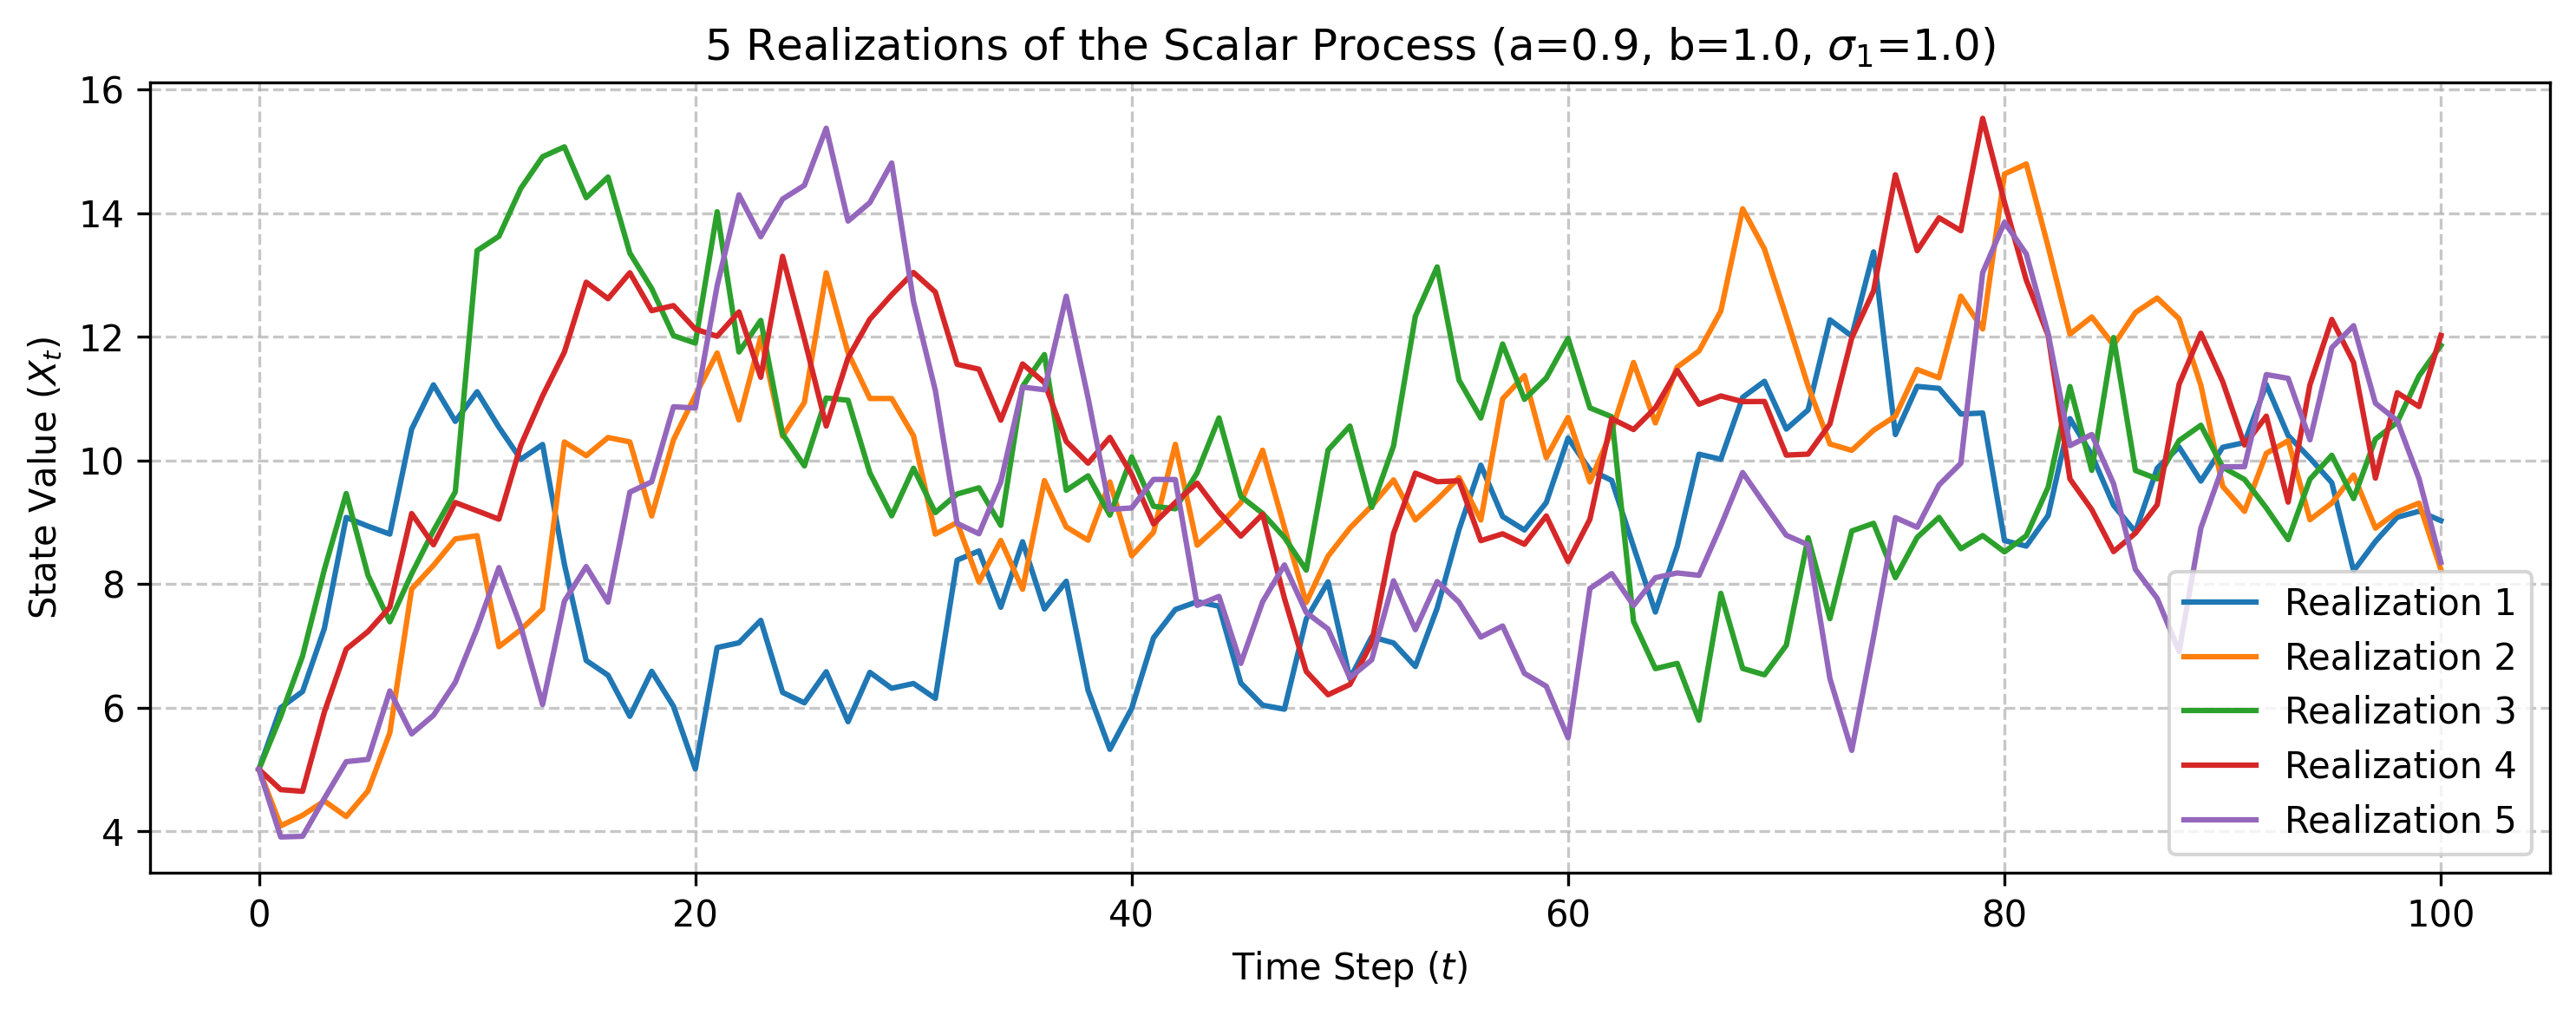

In [307]:
plot_realizations(data, params['a'], params['b'], params['sigma_1'], save_path="plots/1_1_realisations.png")

### 1.2. Simulate a single realization of the process described below using the same parameters as in the previous task
$$X_t = a X_{t-1} + b + e_{1,t}, \quad e_{1,t} \sim \mathcal{N}(0,\sigma_1^2),$$
$$Y_t = X_t + e_{2,t}, \quad e_{2,t} \sim \mathcal{N}(0,\sigma_2^2=1).$$

In [308]:
def simulate_observed_process(a, b, sigma_1, sigma_2, x0, n_steps):
    """
    Simulates a single realization of the latent process and its observations:
    X_t = a * X_{t-1} + b + e1
    Y_t = X_t + e2
    """
    x = np.zeros(n_steps + 1)
    y = np.zeros(n_steps + 1)
    
    x[0] = x0
    # Initial observation at t=0
    y[0] = x[0] + np.random.normal(0, sigma_2)
    
    for t in range(1, n_steps + 1):
        # Update Latent State X_t
        e1 = np.random.normal(0, sigma_1)
        x[t] = a * x[t-1] + b + e1
        
        # Generate Observation Y_t
        e2 = np.random.normal(0, sigma_2)
        y[t] = x[t] + e2
        
    return x, y

In [309]:
def plot_latent_vs_observed(x, y, save_path=None):
    """
    Plots the true state trajectory against noisy observations.
    """
    n_steps = len(x) - 1
    time_axis = np.arange(n_steps + 1)
    
    plt.figure(figsize=(10, 4), dpi=300)
    
    # Plot X_t as a solid line (the "truth")
    plt.plot(time_axis, x, color='blue', linewidth=2, label='Latent State ($X_t$)', zorder=2)
    
    # Plot Y_t as a dashed line (the "noisy data")
    plt.plot(time_axis, y, color='darkorange', linestyle='--', label='Observations ($Y_t$)', zorder=1)

    plt.title('Latent State Trajectory vs. Noisy Observations')
    plt.xlabel('Time Step ($t$)')
    plt.ylabel('Value')
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend()
    plt.tight_layout()
    
    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches="tight")
    
    plt.show()

Set seed for reproducibility

In [310]:
np.random.seed(42)

Run simulation

In [311]:
x_true, y_obs = simulate_observed_process(
    params['a'], params['b'], params['sigma_1'], 
    params['sigma_2'], params['x0'], params['n_steps']
)

Plot and save

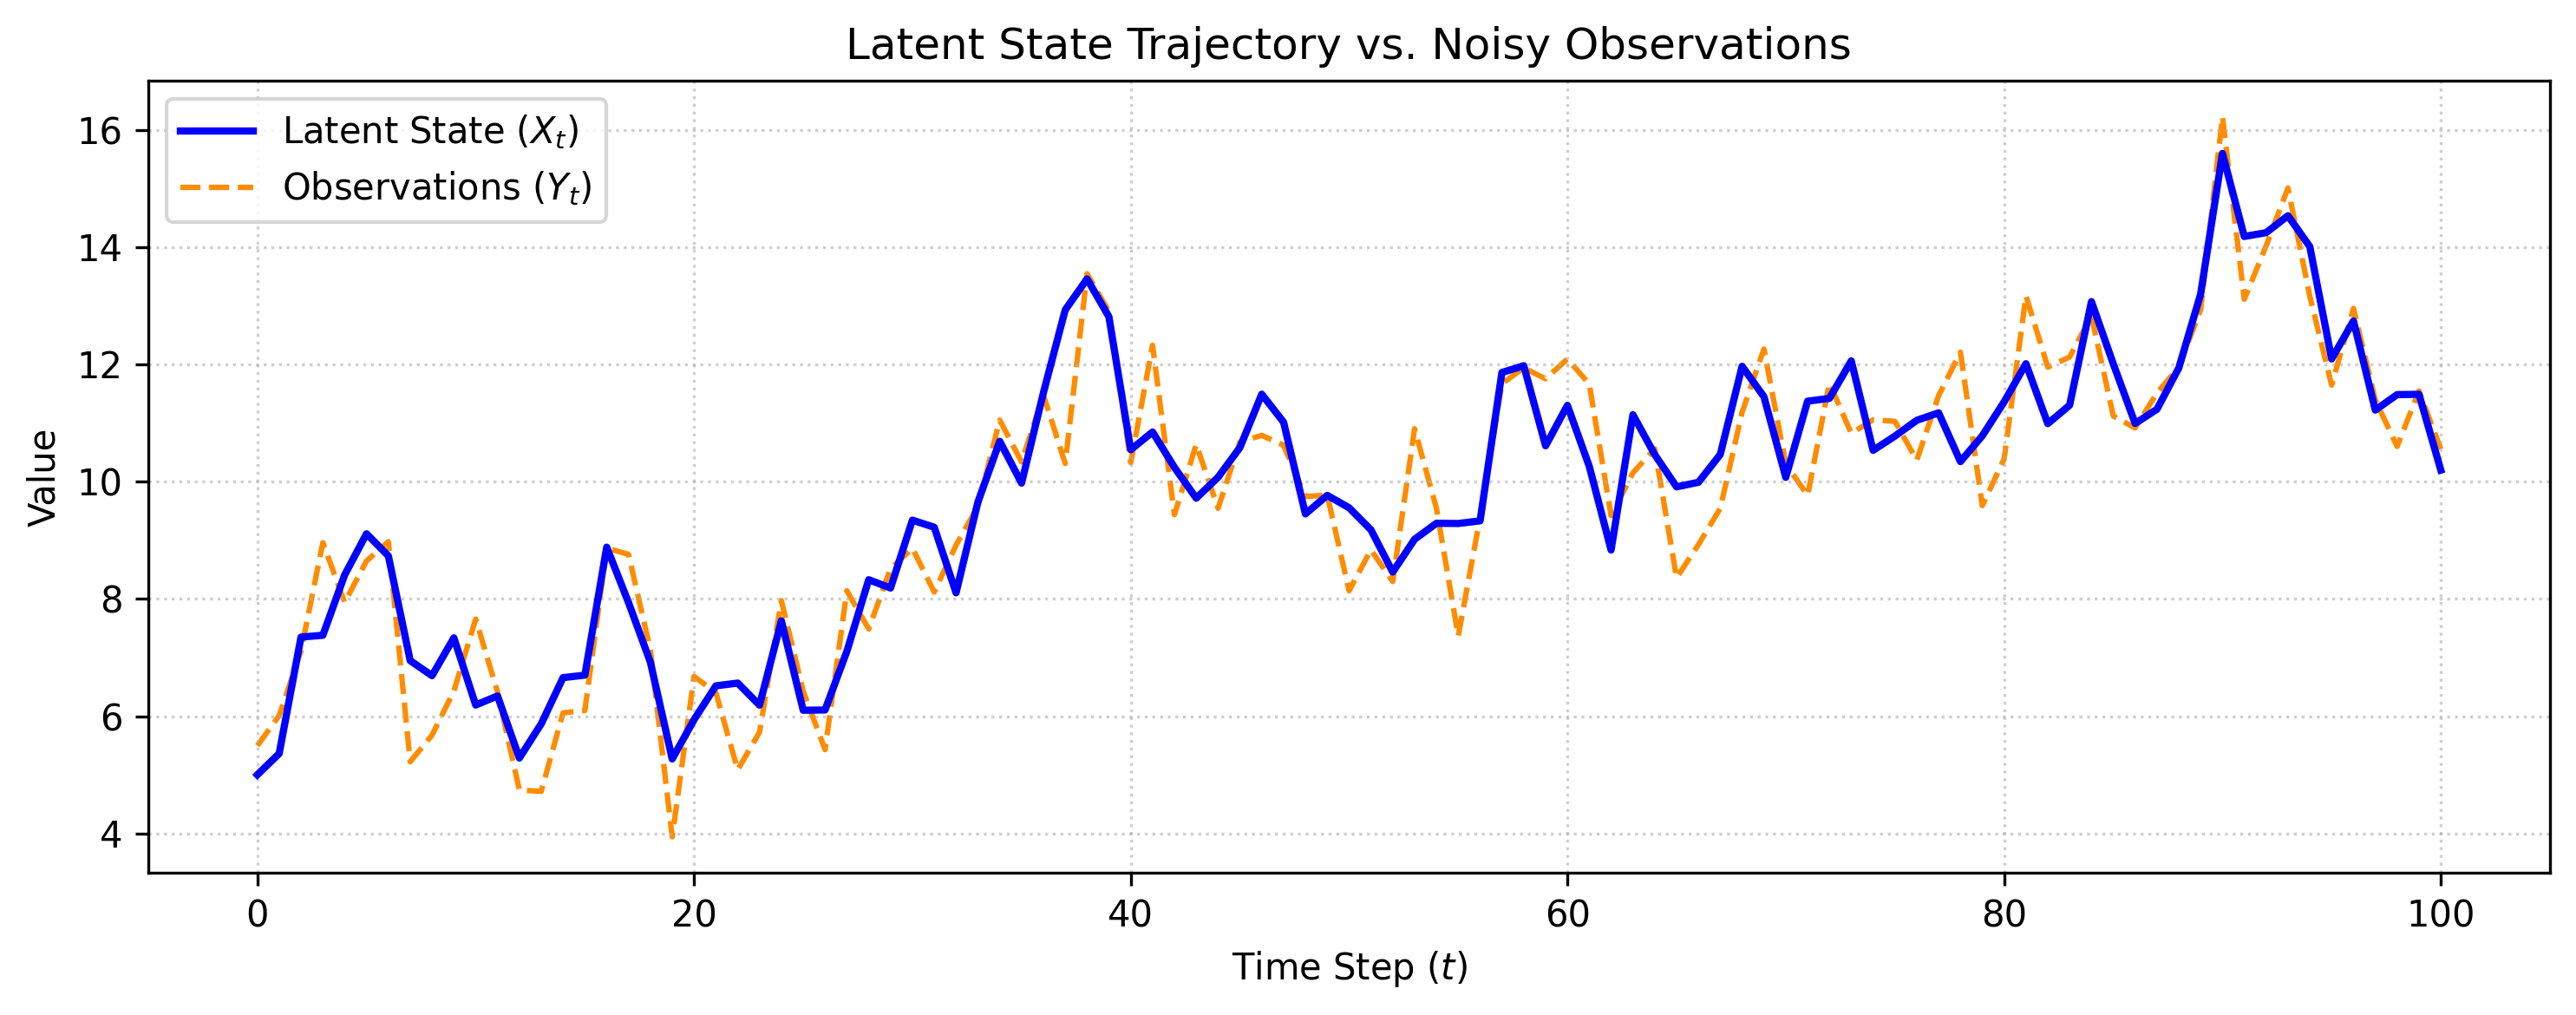

In [312]:
#plot_latent_vs_observed(x_vals, y_vals, save_path="plots/1_2_realisations.png")
plot_latent_vs_observed(x_true, y_obs, save_path="plots/1_2_latent_vs_observed.png")

### 1.3. Kalman filter

R function

In [313]:
def my_kalman_filter(
    y,               # array-like observations
    theta,           # [a, b, sigma1]
    R,               # measurement noise variance
    x_prior=0.0,     # initial mean
    P_prior=10.0     # initial variance
):
    a, b, sigma1 = theta
    N = len(y)

    # Allocate arrays
    x_pred = np.zeros(N)  # Predicted means
    P_pred = np.zeros(N)  # Predicted variances
    x_filt = np.zeros(N)  # Filtered means
    P_filt = np.zeros(N)  # Filtered variances
    innovation = np.zeros(N)  # Pre-fit residuals: y[t] - x_pred[t]
    innovation_var = np.zeros(N)  # Innovation covariance: P_pred[t] + R

    for t in range(N):
        # --- Prediction step ---
        if t == 0:
            x_pred[t] = a * x_prior + b
            P_pred[t] = (a**2) * P_prior + sigma1**2
        else:
            x_pred[t] = a * x_filt[t-1] + b
            P_pred[t] = (a**2) * P_filt[t-1] + sigma1**2

        # --- Update step ---
        innovation[t] = y[t] - x_pred[t]
        innovation_var[t] = P_pred[t] + R

        K_t = P_pred[t] / innovation_var[t]

        x_filt[t] = x_pred[t] + K_t * innovation[t]
        P_filt[t] = (1 - K_t) * P_pred[t]

    return {
        "x_pred": x_pred,
        "P_pred": P_pred,
        "x_filt": x_filt,
        "P_filt": P_filt,
        "innovation": innovation,
        "innovation_var": innovation_var
    }

In [314]:
def plot_kalman_results(x_true, y_obs, kf_results, save_path=None):
    """
    Plots the ground truth, observations, and Kalman Filter predictions with CI.
    """
    n_steps = len(x_true) - 1
    x_pred = kf_results["x_pred"]
    p_pred = kf_results["P_pred"]
    
    # Time axis for predictions (starting at t=1)
    time_filt = np.arange(1, n_steps + 1)
    
    # Calculate 95% Confidence Interval
    ci_upper = x_pred + 1.96 * np.sqrt(p_pred)
    ci_lower = x_pred - 1.96 * np.sqrt(p_pred)

    plt.figure(figsize=(10, 4), dpi=300)

    # Ground Truth and Observations
    plt.plot(np.arange(n_steps + 1), x_true, label='True State ($X_t$)', color='blue', lw=2)
    plt.scatter(time_filt, y_obs[1:], label='Observations ($Y_t$)', color='darkorange', alpha=0.5, s=20)

    # Predicted State
    plt.plot(time_filt, x_pred, label='Predicted State ($\hat{X}_{t|t-1}$)', color='green', linestyle='--')

    # Confidence Interval
    plt.fill_between(time_filt, ci_lower, ci_upper, color='green', alpha=0.15, label='95% Prediction CI')

    plt.title("Kalman Filter: Prediction vs. Reality")
    plt.xlabel("Time ($t$)")
    plt.ylabel("Value")
    plt.grid(True, alpha=0.3)
    plt.legend(loc='upper left')
    plt.tight_layout()

    if save_path:
        os.makedirs(os.path.dirname(save_path), exist_ok=True)
        plt.savefig(save_path, bbox_inches="tight")
    
    plt.show()

<>:23: SyntaxWarning: invalid escape sequence '\h'
<>:23: SyntaxWarning: invalid escape sequence '\h'
C:\Users\manon\AppData\Local\Temp\ipykernel_4648\4202326002.py:23: SyntaxWarning: invalid escape sequence '\h'
  plt.plot(time_filt, x_pred, label='Predicted State ($\hat{X}_{t|t-1}$)', color='green', linestyle='--')


Reuse parameters and simulation function from 1.2

In [315]:
R_val = params['sigma_2']**2

Apply Kalman filter

In [316]:
theta_vals = [params['a'], params['b'], params['sigma_1']]
kf_output = my_kalman_filter(y_obs[1:], theta_vals, R_val, x_prior=params['x0'], P_prior=0)

Plot and save

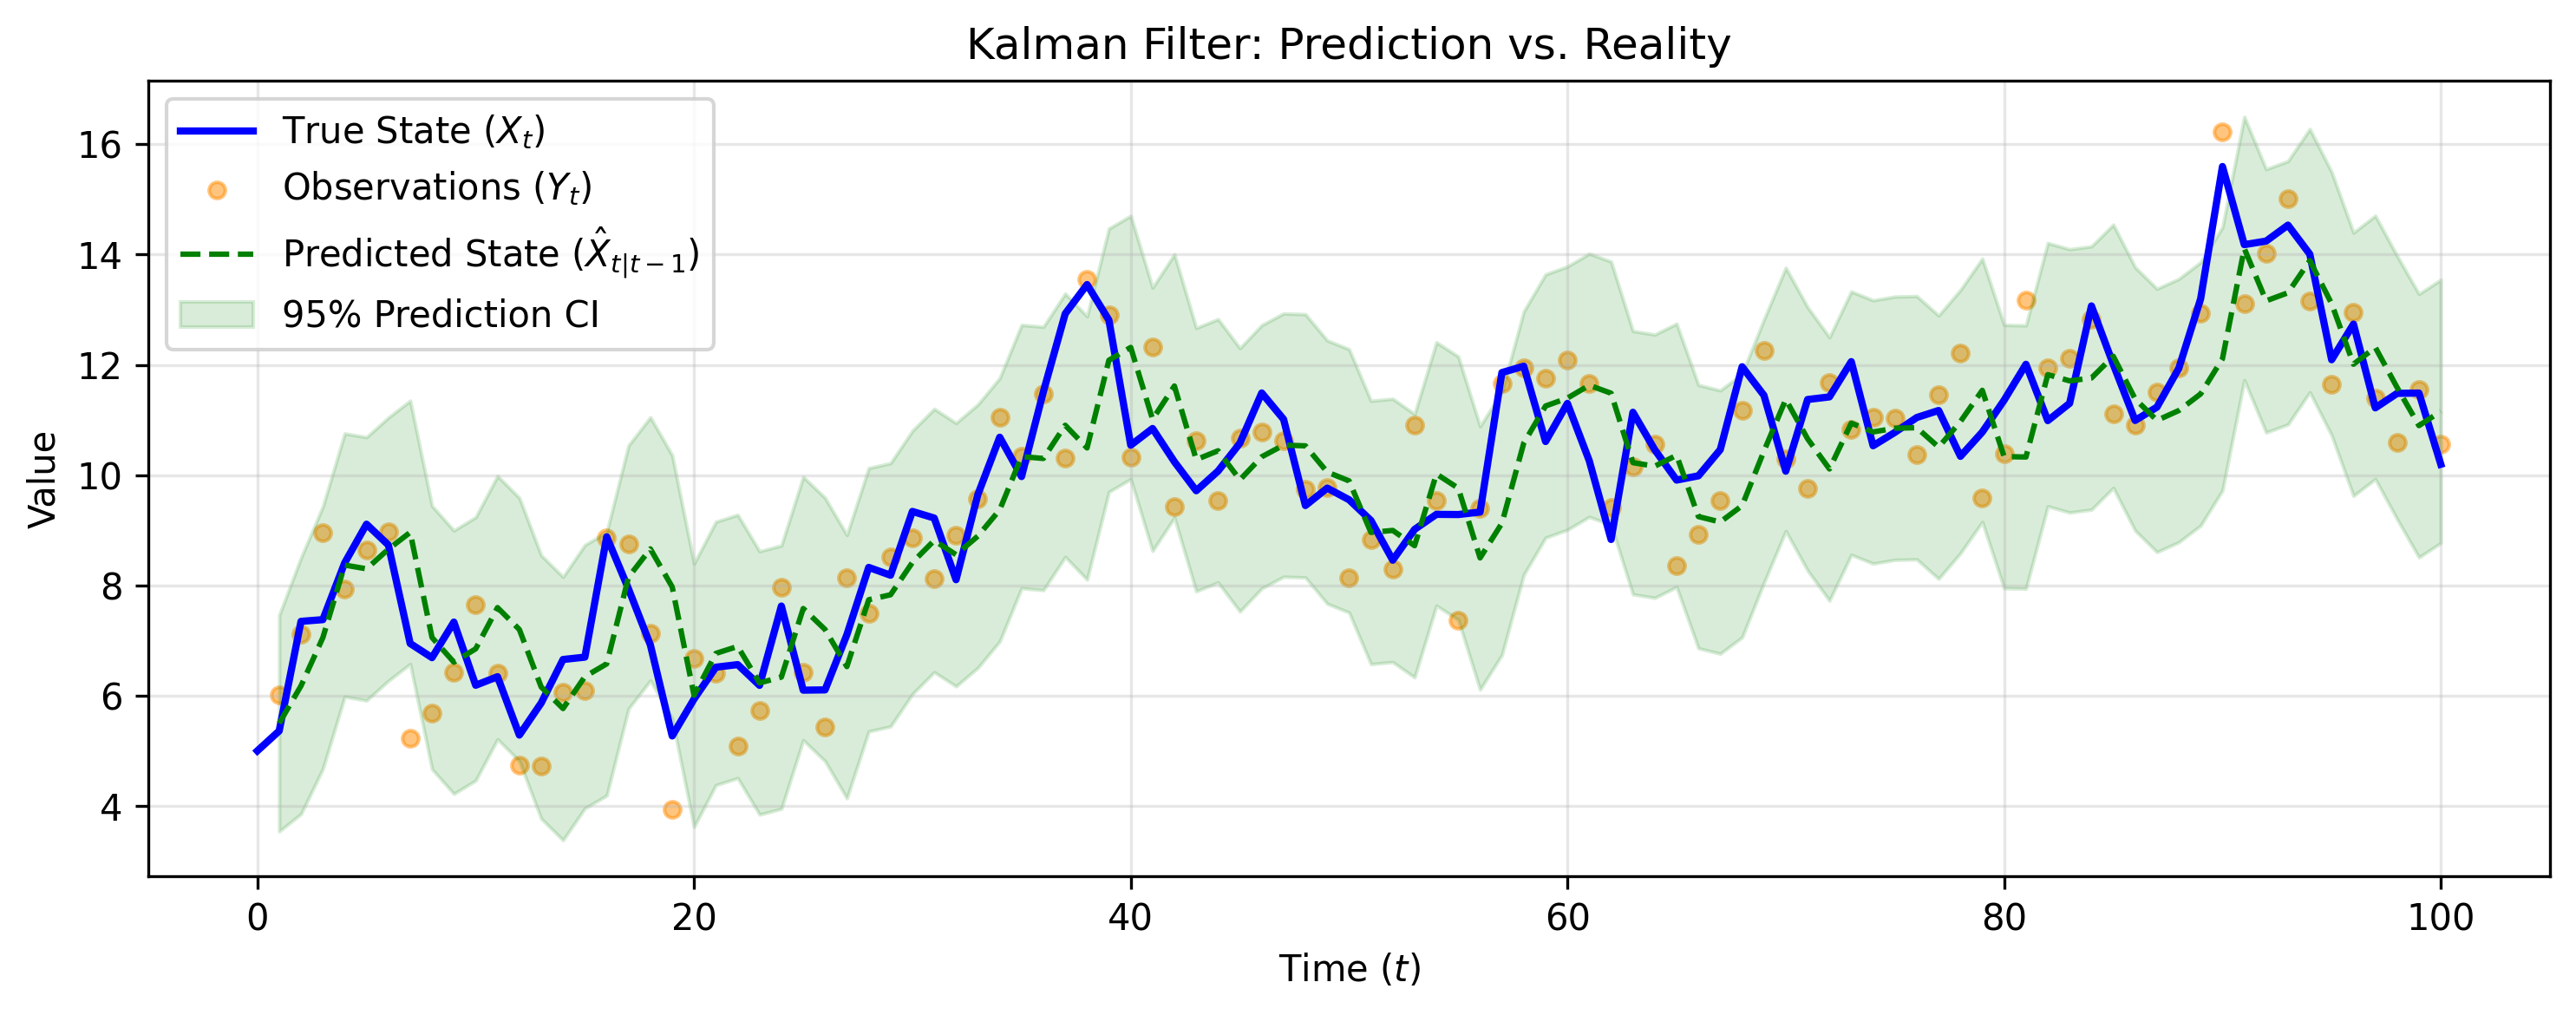

In [317]:
plot_kalman_results(x_true, y_obs, kf_output, save_path="plots/1_3_kalman_filter.png")

### 1.4. Estimate parameters from noisy observations using the maximum likelihood framework

R function

In [318]:
def my_log_lik_fun(theta, y, R, x_prior=0, P_prior=10):
    """
    Computes the negative log-likelihood of a scalar state-space model 
    using the Kalman Filter innovations.
    """
    # 1. Run the Kalman Filter with the current theta parameters
    kf_result = my_kalman_filter(y, theta, R, x_prior, P_prior)
    
    err = kf_result["innovation"]      # nu_t
    S = kf_result["innovation_var"]    # S_t
    
    # 2. Compute the log-likelihood for each time step
    logL_terms = -0.5 * (np.log(2 * np.pi) + np.log(S) + (err**2) / S)
    
    # 3. Sum the contributions
    logL = np.sum(logL_terms)
    return -logL

In [319]:
def estimate_parameters(y_obs, R, x_prior):
    """
    Uses scipy.optimize to find the MLE of theta = [a, b, sigma1].
    """
    # Initial guess [a, b, sigma1]
    initial_guess = [0.5, 0.5, 2.0]
    
    # Bounds: a and b are unrestricted, sigma1 must be > 1e-4
    bounds = [(None, None), (None, None), (1e-4, None)]
    
    # Minimize the negative log-likelihood
    res = minimize(
        fun=my_log_lik_fun, 
        x0=initial_guess, 
        args=(y_obs, R, x_prior), 
        bounds=bounds,
        method='L-BFGS-B'
    )
    
    return res.x if res.success else [np.nan, np.nan, np.nan]

In [320]:
def summarize_estimation_results(all_results, scenarios):
    """
    Calculates summary statistics for each scenario and prints them as tables.
    """
    param_names = ['a', 'b', 'sigma_1']
    
    for sc in scenarios:
        label = sc['label']
        data = all_results[label]
        
        # Create a DataFrame for the current scenario
        df = pd.DataFrame(data, columns=param_names)
        
        # Calculate statistics
        summary = df.describe().loc[['mean', 'std', '50%']] # 50% is the median
        summary.rename(index={'50%': 'median'}, inplace=True)
        
        # Add a row for the True Values to allow easy comparison
        true_vals = pd.Series({'a': sc['a'], 'b': sc['b'], 'sigma_1': sc['sigma_1']}, name='True Value')
        summary = pd.concat([pd.DataFrame([true_vals]), summary])
        
        print(f"\n{'='*40}")
        print(f"RESULTS FOR: {label}")
        print(f"{'='*40}")
        print(summary.round(4)) # Rounding for readability
        print("\n")

Scenarios

In [321]:
scenarios = [
    {'a': 1.0, 'b': 0.9, 'sigma_1': 1.0, 'label': "a=1, b=0.9, s1=1"},
    {'a': 5.0, 'b': 0.9, 'sigma_1': 1.0, 'label': "a=5, b=0.9, s1=1"},
    {'a': 1.0, 'b': 0.9, 'sigma_1': 5.0, 'label': "a=1, b=0.9, s1=5"}
]

In [322]:
n_realizations = 100
n_steps = 100
sigma_2 = 1.0
R_val = sigma_2**2
x0 = 5.0

In [323]:
# Dictionary to store results for plotting
all_results = {}

for sc in scenarios:
    print(f"Processing Scenario: {sc['label']}...")
    estimates = []
    
    for _ in range(n_realizations):
        # 1. Simulate using the scenario's true values
        x_true, y_obs = simulate_observed_process(
            sc['a'], sc['b'], sc['sigma_1'], sigma_2, x0, n_steps
        )
        
        # 2. Estimate (passing y_obs[1:] to the filter)
        theta_hat = estimate_parameters(y_obs[1:], R_val, x0)
        estimates.append(theta_hat)
    
    all_results[sc['label']] = np.array(estimates)

Processing Scenario: a=1, b=0.9, s1=1...
Processing Scenario: a=5, b=0.9, s1=1...


C:\Users\manon\AppData\Local\Temp\ipykernel_4648\1043859908.py:13: RuntimeWarning: overflow encountered in square
  logL_terms = -0.5 * (np.log(2 * np.pi) + np.log(S) + (err**2) / S)
C:\Users\manon\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\scipy\optimize\_numdiff.py:592: RuntimeWarning: invalid value encountered in subtract
  df = fun(x1) - f0


Processing Scenario: a=1, b=0.9, s1=5...


Table

In [324]:
summarize_estimation_results(all_results, scenarios)


RESULTS FOR: a=1, b=0.9, s1=1
                 a       b  sigma_1
True Value  1.0000  0.9000   1.0000
mean        0.9996  0.9407   0.9285
std         0.0041  0.2268   0.1790
median      0.9993  0.9321   0.9281



RESULTS FOR: a=5, b=0.9, s1=1
                 a    b  sigma_1
True Value  5.0000  0.9   1.0000
mean        1.0484  0.5   2.8362
std         0.0000  0.0   0.0000
median      1.0484  0.5   2.8362



RESULTS FOR: a=1, b=0.9, s1=5
                 a       b  sigma_1
True Value  1.0000  0.9000   5.0000
mean        0.9813  1.8206   4.9651
std         0.0199  1.2115   0.3354
median      0.9841  1.5186   4.9427




Visualization

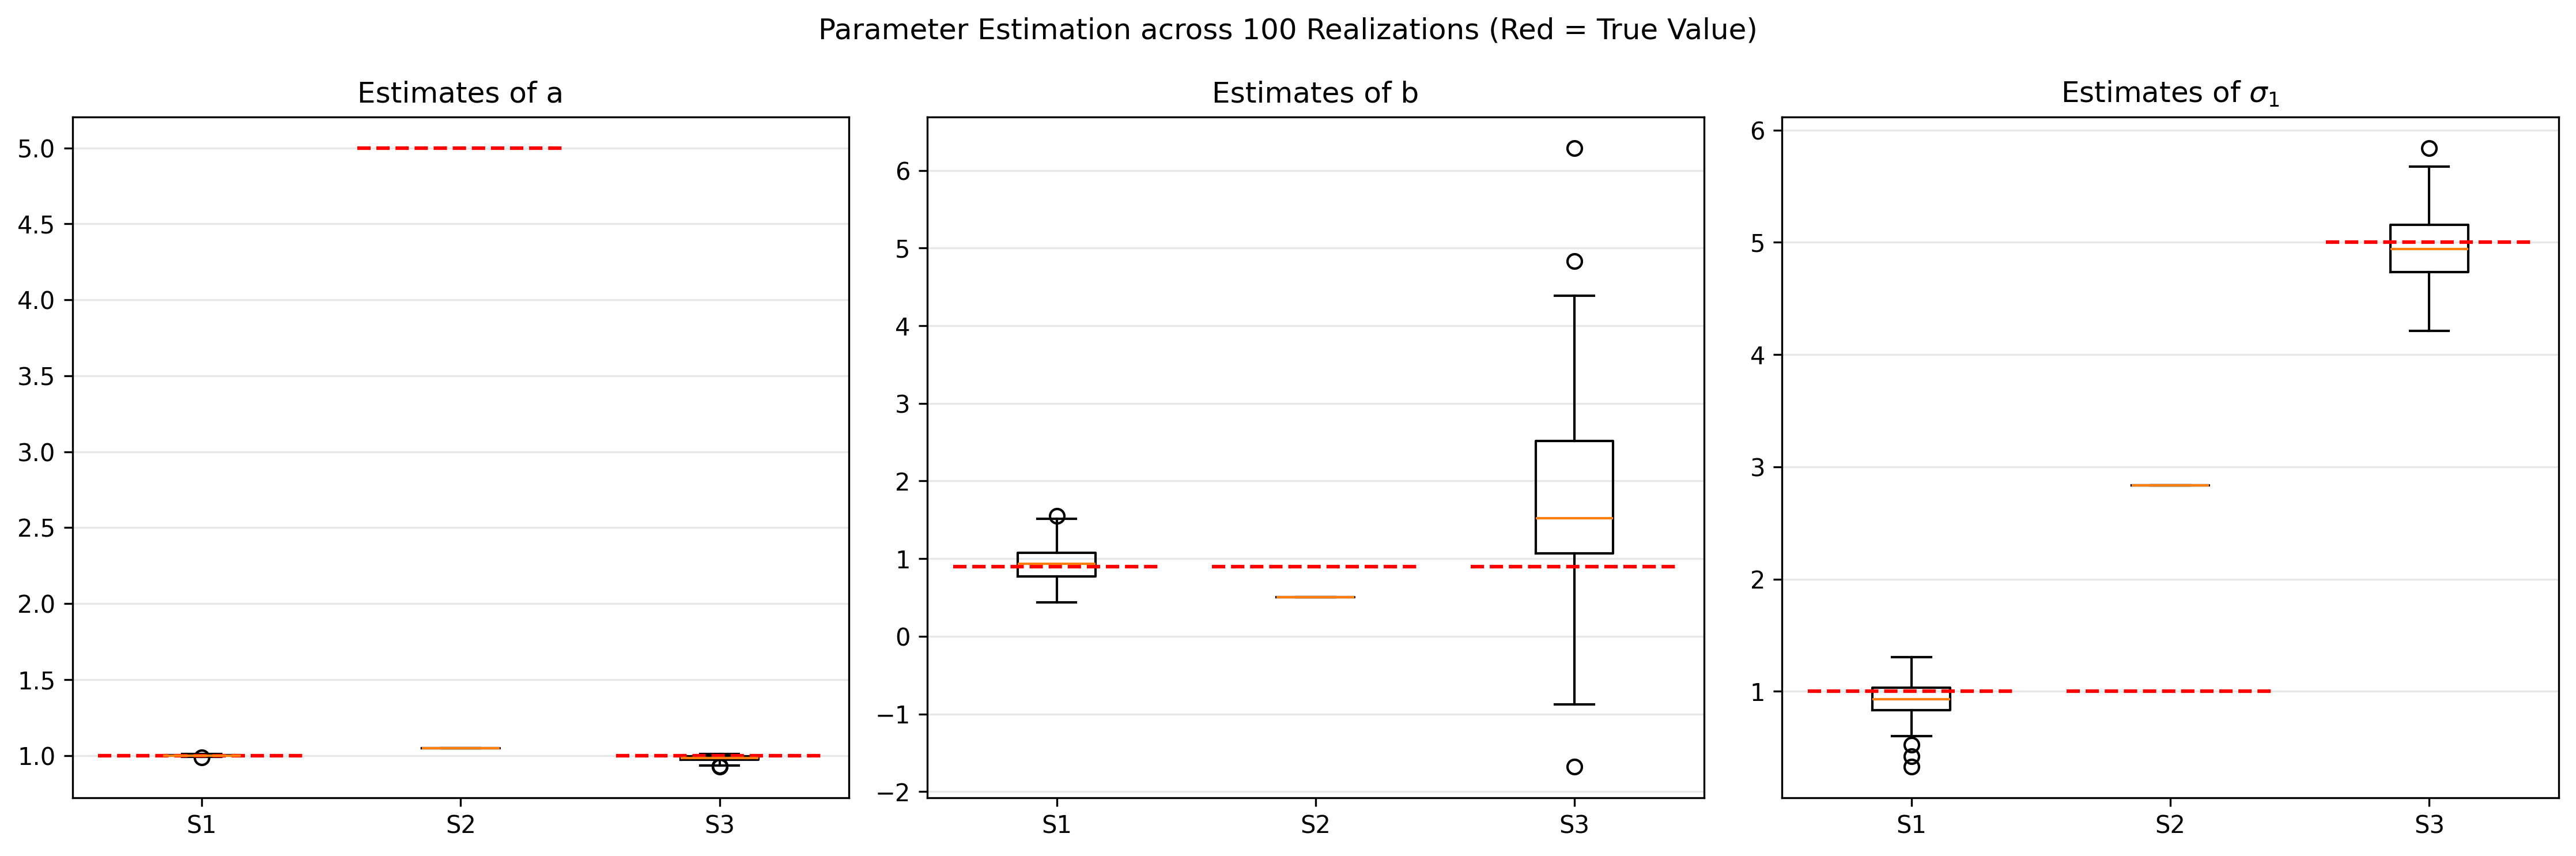

In [325]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5), dpi=300)
param_names = ['a', 'b', r'$\sigma_1$']

for i, ax in enumerate(axes):
    # Prepare data for boxplot
    data_to_plot = [all_results[sc['label']][:, i] for sc in scenarios]
    
    ax.boxplot(data_to_plot, labels=['S1', 'S2', 'S3'])
    ax.set_title(f'Estimates of {param_names[i]}')
    ax.grid(True, axis='y', alpha=0.3)
    
    # Add red horizontal lines for true values in Scenario 1 (as an example)
    # Or plot specific markers for each scenario's truth
    for j, sc in enumerate(scenarios):
        true_val = [sc['a'], sc['b'], sc['sigma_1']][i]
        ax.hlines(true_val, j + 0.6, j + 1.4, colors='red', linestyles='--')

plt.suptitle("Parameter Estimation across 100 Realizations (Red = True Value)")
plt.tight_layout()
os.makedirs("plots", exist_ok=True)
plt.savefig("plots/1_4_parameter_estimation.png")
plt.show()

### 1.5. Simulating system noise from a Student’s t-distribution

In [334]:
def simulate_t_process(a, b, sigma_1, sigma_2, x0, n_steps, nu):
    """
    Simulates:
    X_t = a*X_{t-1} + b + sigma_1 * lambda_t, where lambda_t ~ t(nu)
    Y_t = X_t + e2_t, where e2_t ~ N(0, sigma_2^2)
    """
    x = np.zeros(n_steps + 1)
    y = np.zeros(n_steps + 1)
    x[0] = x0
    y[0] = x[0] + np.random.normal(0, sigma_2)
    
    for t_idx in range(1, n_steps + 1):
        # Generate t-distributed noise
        lambda_t = np.random.standard_t(df=nu)
        x[t_idx] = a * x[t_idx-1] + b + (sigma_1 * lambda_t)
        
        # Generate Gaussian observation noise
        y[t_idx] = x[t_idx] + np.random.normal(0, sigma_2)
        
    return x, y

In [345]:
def plot_t_densities(nu_values):
    plt.figure(figsize=(10, 4), dpi=300)
    x_range = np.linspace(-5, 5, 500)
    
    # Plot Standard Normal for reference
    plt.plot(x_range, norm.pdf(x_range), 'k--', lw=2, label='Normal (Gaussian)')
    
    # Plot T-distributions
    colors = ['tab:blue', 'tab:orange', 'tab:green', 'tab:red']
    for nu, color in zip(nu_values, colors):
        plt.plot(x_range, t.pdf(x_range, df=nu), color=color, label=f't(ν={nu})')
    
    plt.title('Comparison of Normal and Student\'s t-Distributions')
    plt.xlabel('Value')
    plt.ylabel('Density')
    plt.legend()
    plt.grid(True, alpha=0.3)
    os.makedirs("plots", exist_ok=True)
    plt.savefig("plots/1_5_t_densities.png")
    plt.show()

In [349]:
def summarize_t_estimation(t_results, nu_list, true_params):
    """
    Generates summary tables for each nu scenario.
    """
    param_names = ['a', 'b', 'sigma_1']
    
    for nu in nu_list:
        data = t_results[nu]
        df = pd.DataFrame(data, columns=param_names)
        
        # Calculate summary stats
        summary = df.describe().loc[['mean', 'std', '50%']]
        summary.rename(index={'50%': 'median'}, inplace=True)
        
        # Add True Values row
        true_row = pd.Series(true_params, index=param_names, name='True Value')
        summary = pd.concat([pd.DataFrame([true_row]), summary])
        
        print(f"{'='*45}")
        print(f"ESTIMATION SUMMARY: Student's t (nu = {nu})")
        print(f"{'='*45}")
        print(summary.round(4))
        print("\n")

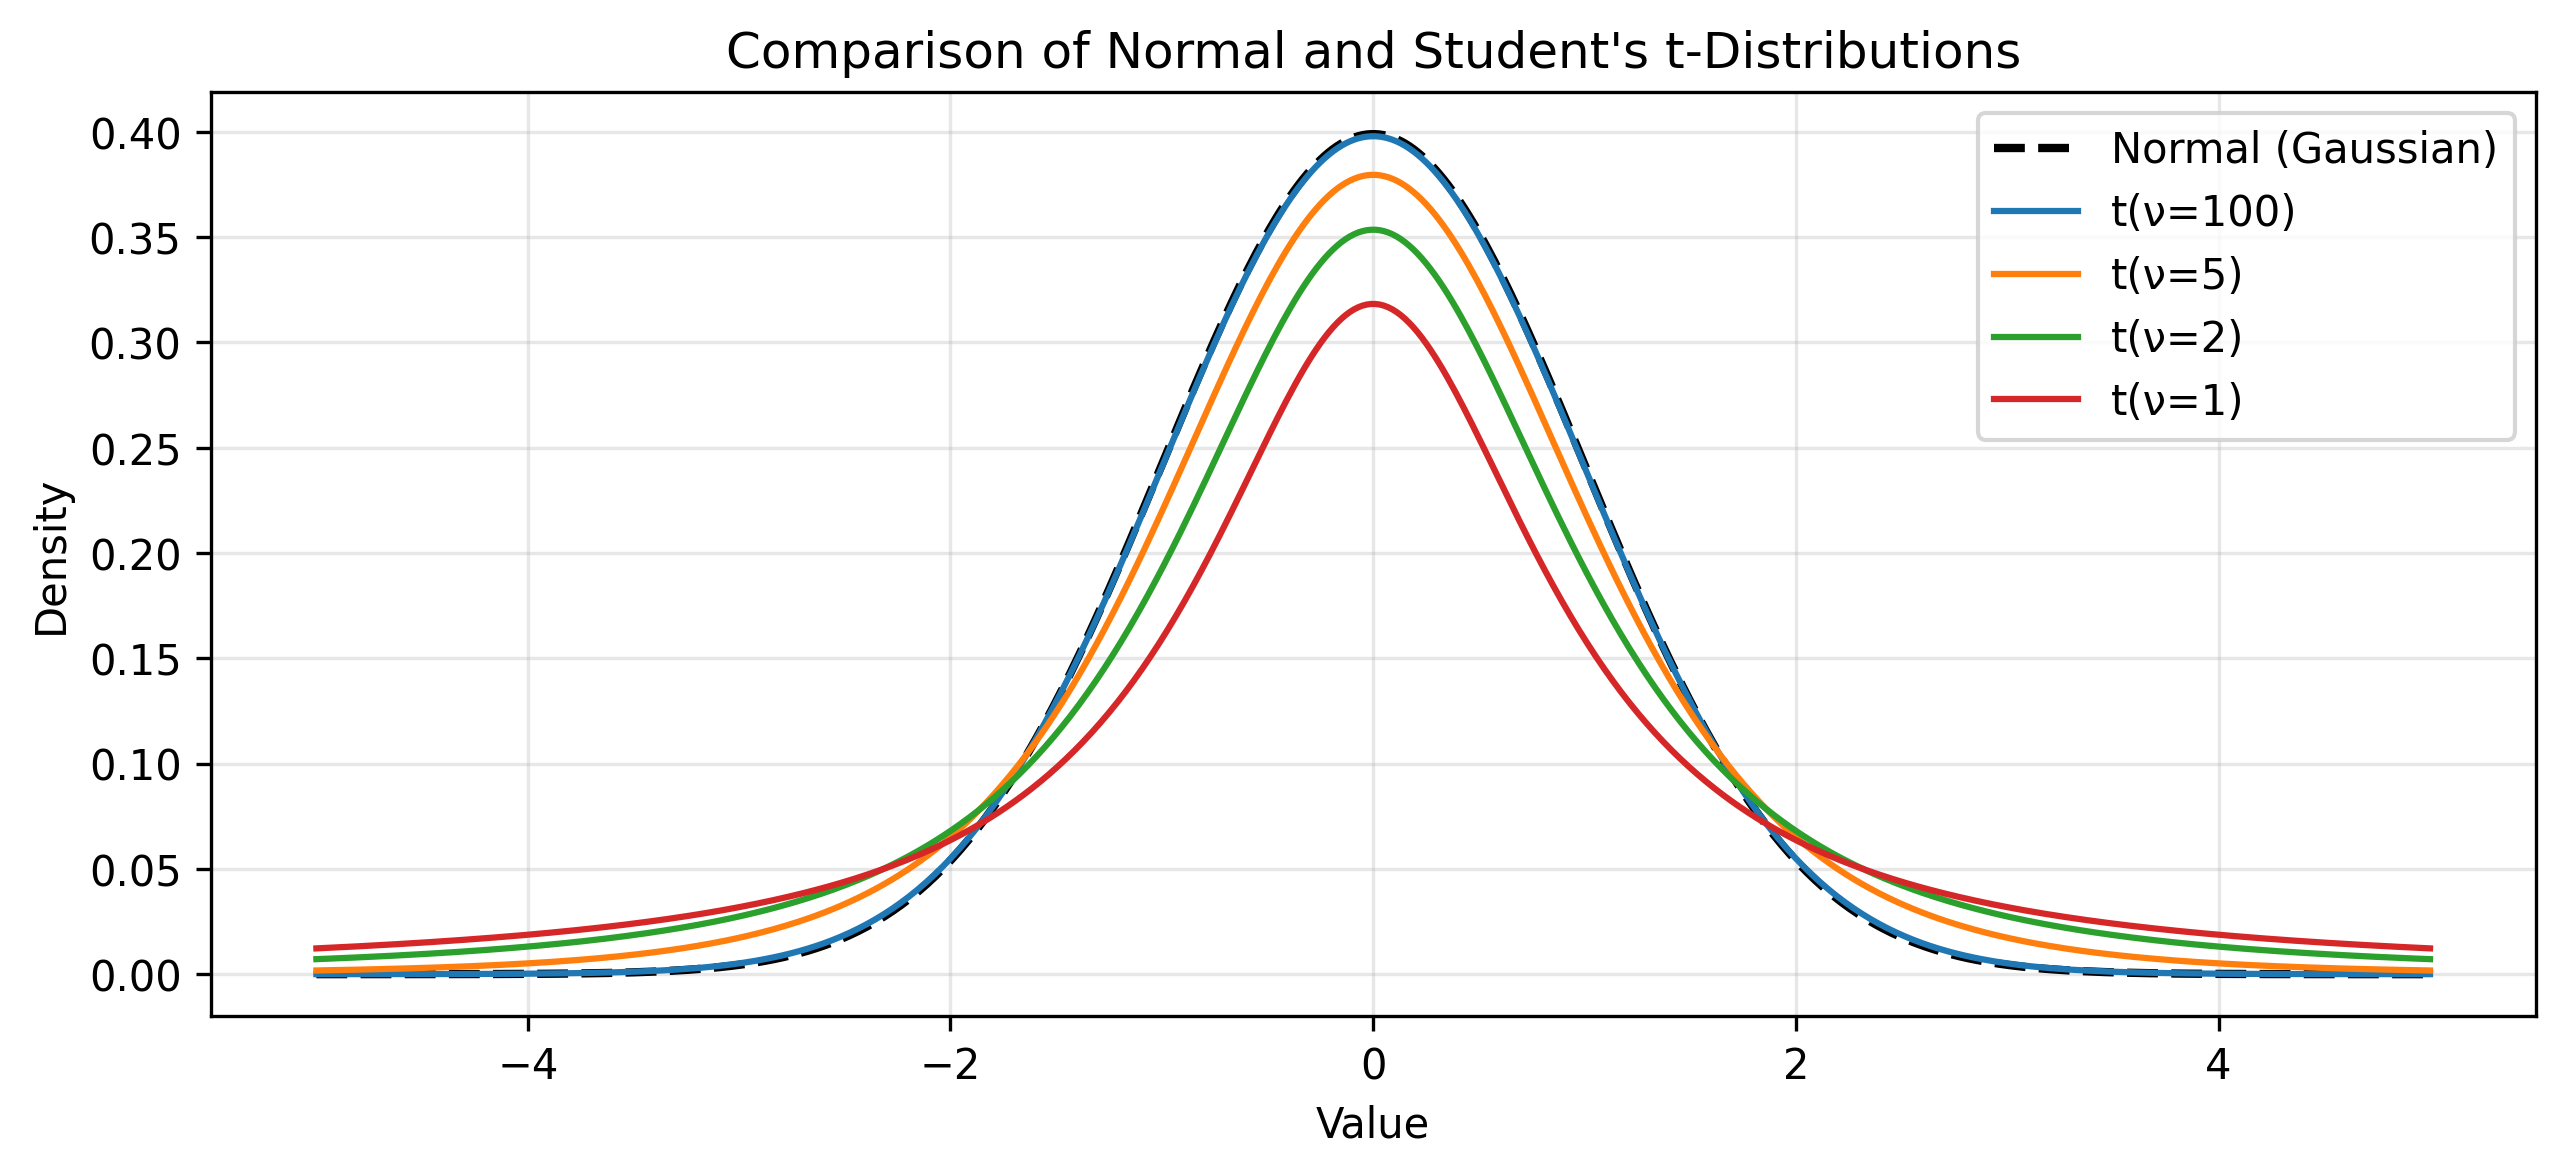

In [346]:
nu_list = [100, 5, 2, 1]
plot_t_densities(nu_list)

Parameters

In [337]:
params_t = {
    'a': 1.0, 
    'b': 0.9, 
    'sigma_1': 1.0, 
    'sigma_2': 1.0,
    'x0': 5.0, 
    'n_steps': 100
}
R_val = params_t['sigma_2']**2
n_realizations = 100

Simulations

In [338]:
t_results = {}

for nu in nu_list:
    print(f"Simulating ν = {nu}...")
    estimates = []
    for _ in range(n_realizations):
        # Simulate with t-noise
        x_t, y_t = simulate_t_process(
            params_t['a'], params_t['b'], params_t['sigma_1'], 
            params_t['sigma_2'], params_t['x0'], params_t['n_steps'], nu
        )
        
        # Estimate using the Gaussian Kalman Filter Likelihood
        theta_hat = estimate_parameters(y_t[1:], R_val, params_t['x0'])
        estimates.append(theta_hat)
    
    t_results[nu] = np.array(estimates)

Simulating ν = 100...
Simulating ν = 5...
Simulating ν = 2...
Simulating ν = 1...


Plotting

C:\Users\manon\AppData\Local\Temp\ipykernel_4648\4207251302.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='nu', y=param, data=df_all_t, ax=axes[i], palette="viridis")
C:\Users\manon\AppData\Local\Temp\ipykernel_4648\4207251302.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='nu', y=param, data=df_all_t, ax=axes[i], palette="viridis")
C:\Users\manon\AppData\Local\Temp\ipykernel_4648\4207251302.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='nu', y=param, data=df_all_t, ax=axes[i], palette="viridis")


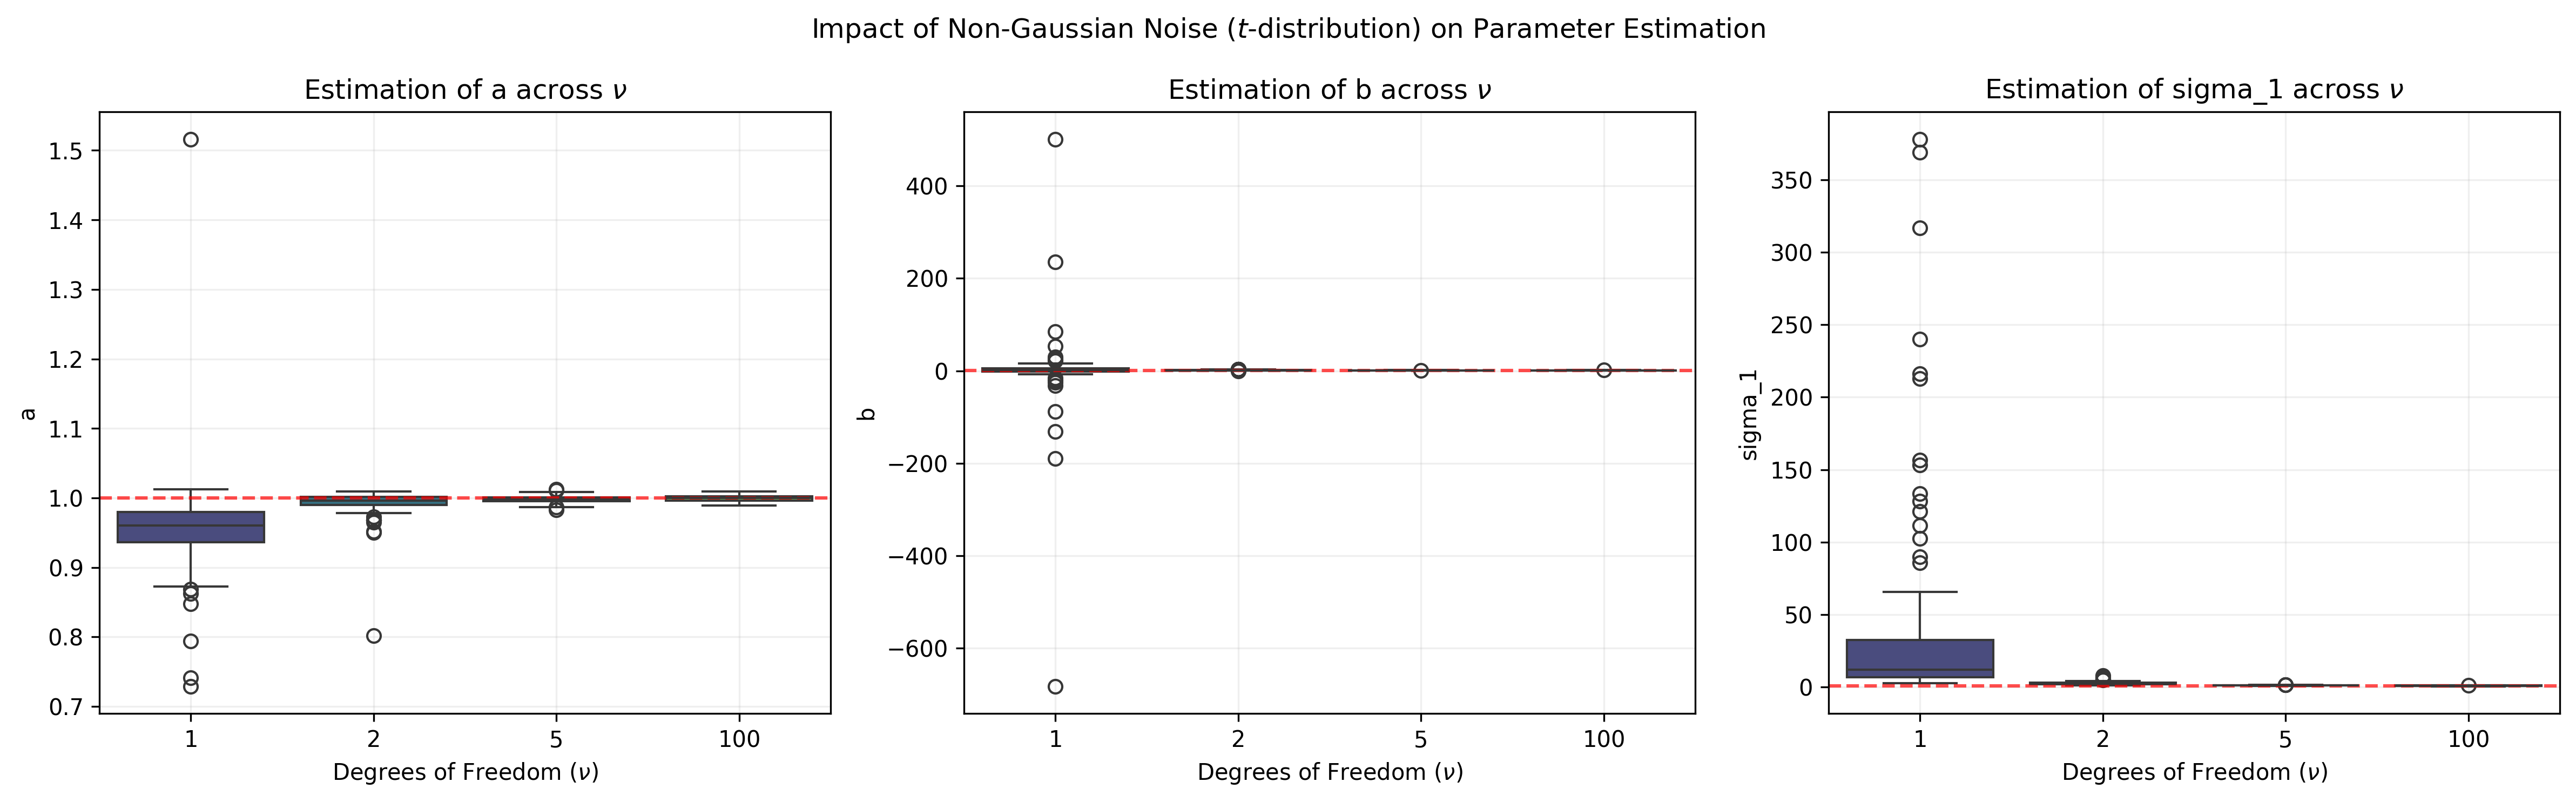

In [348]:
# We reuse the t_results dictionary from the previous step
# nu_list = [100, 5, 2, 1]

# Prepare data for visualization
plot_data = []
for nu in nu_list:
    df_temp = pd.DataFrame(t_results[nu], columns=['a', 'b', 'sigma_1'])
    df_temp['nu'] = nu
    plot_data.append(df_temp)

df_all_t = pd.concat(plot_data)

# Create the comparison plots
fig, axes = plt.subplots(1, 3, figsize=(16, 5), dpi=300)
param_names = ['a', 'b', 'sigma_1']
true_vals = [1.0, 0.9, 1.0]

for i, param in enumerate(param_names):
    sns.boxplot(x='nu', y=param, data=df_all_t, ax=axes[i], palette="viridis")
    axes[i].axhline(true_vals[i], color='red', linestyle='--', alpha=0.7, label='True Value')
    axes[i].set_title(f'Estimation of {param} across $\\nu$')
    axes[i].set_xlabel('Degrees of Freedom ($\\nu$)')
    axes[i].grid(True, alpha=0.2)

plt.suptitle("Impact of Non-Gaussian Noise ($t$-distribution) on Parameter Estimation")
plt.tight_layout()
plt.savefig("plots/1_5_t_distribution_comparison.png")
plt.show()

Table

In [350]:
summarize_t_estimation(t_results, [100, 5, 2, 1], [1.0, 0.9, 1.0])

ESTIMATION SUMMARY: Student's t (nu = 100)
                 a       b  sigma_1
True Value  1.0000  0.9000   1.0000
mean        0.9996  0.9373   0.9319
std         0.0044  0.2403   0.1404
median      0.9998  0.9443   0.9324


ESTIMATION SUMMARY: Student's t (nu = 5)
                 a       b  sigma_1
True Value  1.0000  0.9000   1.0000
mean        0.9980  0.9933   1.2245
std         0.0047  0.2573   0.1933
median      0.9980  0.9838   1.2333


ESTIMATION SUMMARY: Student's t (nu = 2)
                 a       b  sigma_1
True Value  1.0000  0.9000   1.0000
mean        0.9914  1.2662   2.5725
std         0.0222  0.6155   1.1030
median      0.9962  1.1449   2.3750


ESTIMATION SUMMARY: Student's t (nu = 1)
                 a        b  sigma_1
True Value  1.0000   0.9000   1.0000
mean        0.9544  -0.0800  41.7646
std         0.0745  92.6819  73.1423
median      0.9603   2.3561  12.1425


